In [1]:
import numpy as np
import matplotlib.pyplot as plt

### energia para todoas las particulas (all)

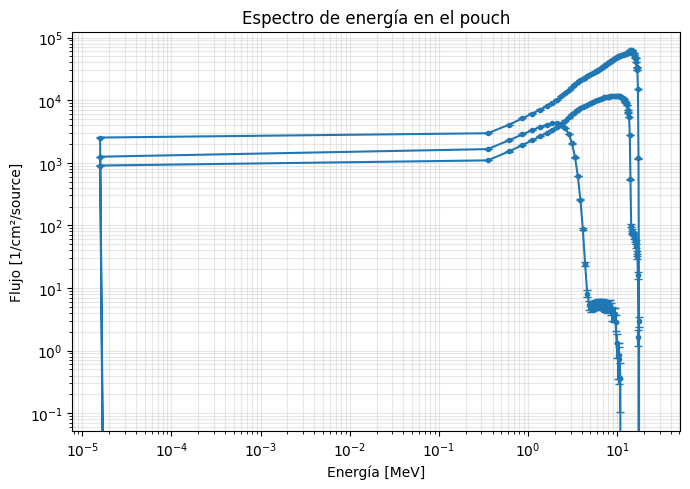

In [2]:
archivo = "energy_pouch.out"

E = []
flujo = []
error = []

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for linea in f:
        partes = linea.split()

        if len(partes) < 4:
            continue

        try:
            e1 = float(partes[0].replace("D", "E"))
            e2 = float(partes[1].replace("D", "E"))
            val = float(partes[2].replace("D", "E"))
            err = float(partes[3].replace("D", "E"))
        except:
            continue

        E.append(np.sqrt(e1 * e2))
        flujo.append(val)
        error.append(err)

E = np.array(E)
flujo = np.array(flujo)
error = np.array(error)

plt.figure(figsize=(7,5))

plt.errorbar(
    E,
    flujo,
    yerr=flujo * error,
    fmt="o-",
    capsize=3,
    markersize=3
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Energía [MeV]")
plt.ylabel("Flujo [1/cm²/source]")
plt.title("Espectro de energía en el pouch")

plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

### energia para todas las partículas por separado (proton neutron alpha photon positron)

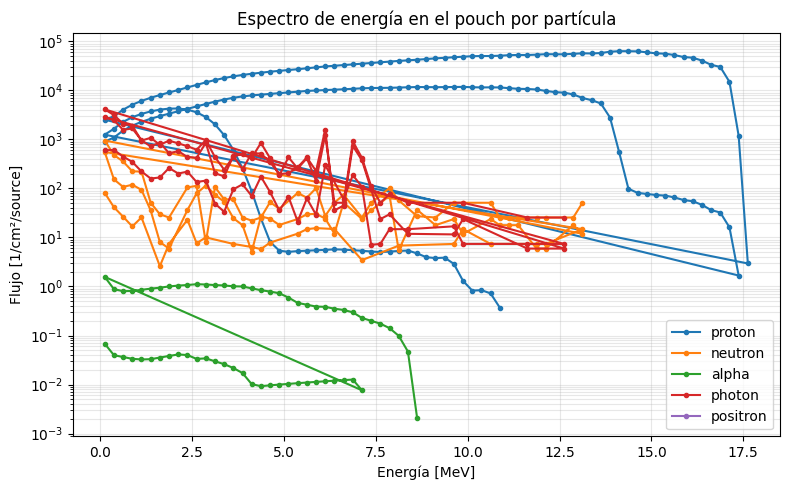

In [3]:
archivo = "energy_pouch.out"

E = []

proton = []
neutron = []
alpha = []
photon = []
positron = []

err_proton = []
err_neutron = []
err_alpha = []
err_photon = []
err_positron = []

leer = False

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for linea in f:
        if linea.strip().startswith("#  e-lower"):
            leer = True
            continue

        if leer:
            partes = linea.split()

            if len(partes) != 12:
                continue

            try:
                valores = [float(p.replace("D", "E")) for p in partes]
            except:
                continue

            e1, e2 = valores[0], valores[1]

            E.append((e1 + e2) / 2)

            proton.append(valores[2])
            err_proton.append(valores[3])

            neutron.append(valores[4])
            err_neutron.append(valores[5])

            alpha.append(valores[6])
            err_alpha.append(valores[7])

            photon.append(valores[8])
            err_photon.append(valores[9])

            positron.append(valores[10])
            err_positron.append(valores[11])

E = np.array(E)

datos = {
    "proton": np.array(proton),
    "neutron": np.array(neutron),
    "alpha": np.array(alpha),
    "photon": np.array(photon),
    "positron": np.array(positron),
}

plt.figure(figsize=(8,5))

for nombre, y in datos.items():
    mask = y > 0
    plt.plot(E[mask], y[mask], marker="o", markersize=3, linewidth=1.5, label=nombre)

plt.yscale("log")
plt.xlabel("Energía [MeV]")
plt.ylabel("Flujo [1/cm²/source]")
plt.title("Espectro de energía en el pouch por partícula")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

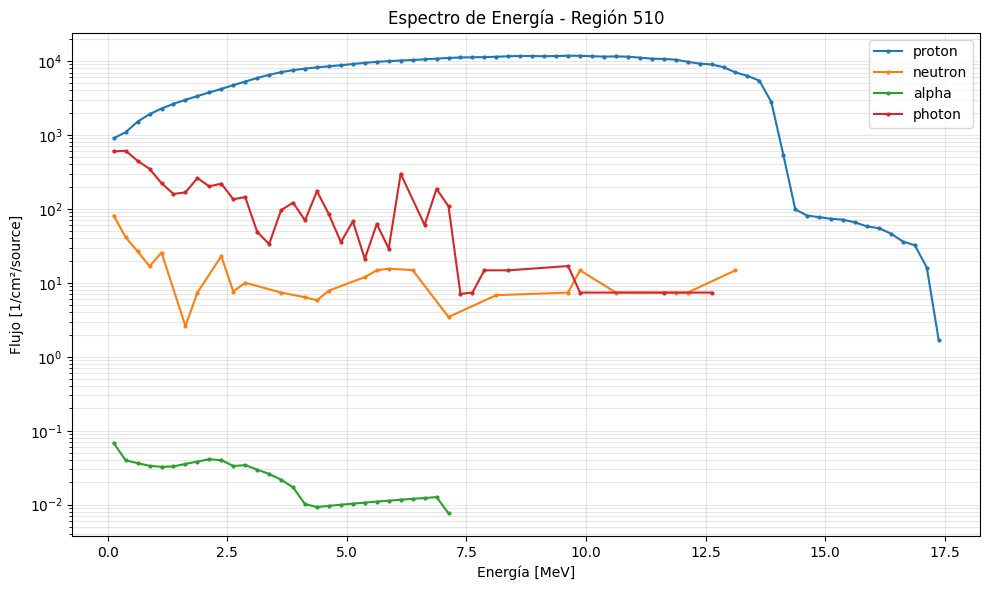

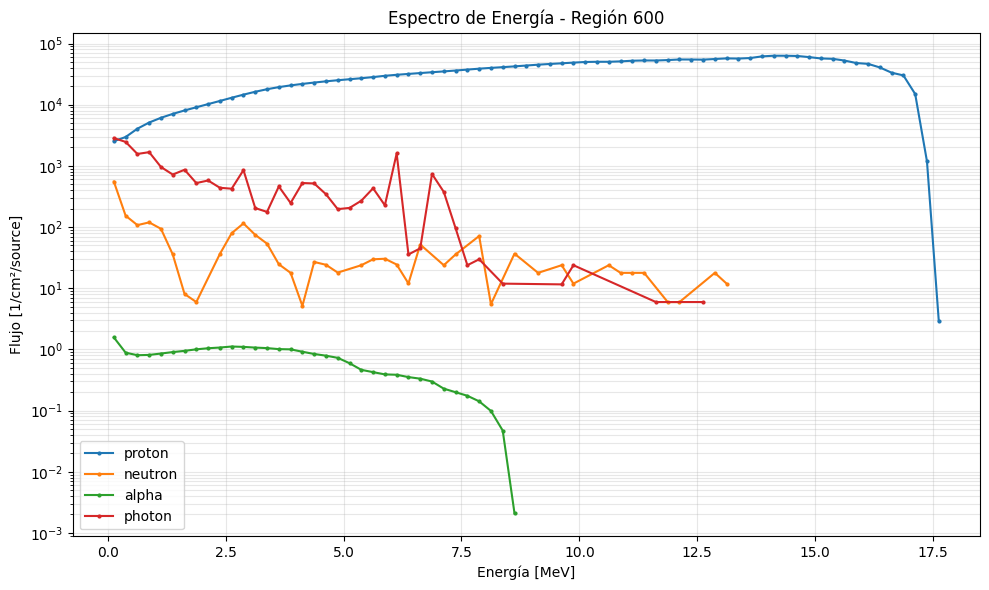

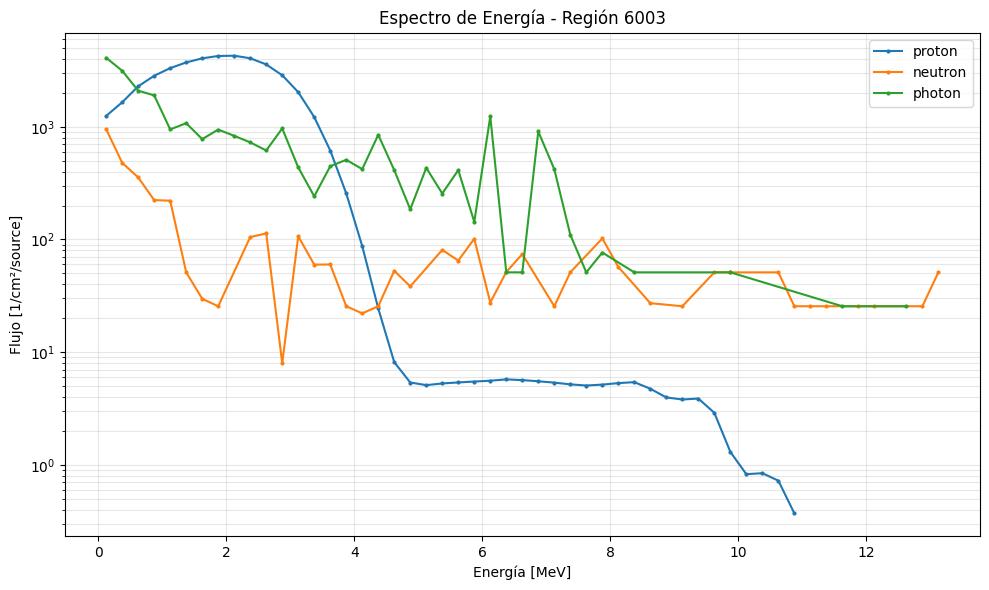

In [4]:
archivo = "energy_pouch.out"

datos_regiones = {}
particulas = ["proton", "neutron", "alpha", "photon", "positron"]
reg_actual = None
leer_datos = False

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for linea in f:
        linea_strip = linea.strip().lower()
        
        # 1. Detectar región
        if "reg =" in linea_strip:
            try:
                reg_actual = linea_strip.split("reg =")[1].split()[0].replace(",", "")
                if reg_actual not in datos_regiones:
                    datos_regiones[reg_actual] = {p: {"E": [], "y": [], "err": []} for p in particulas}
                leer_datos = False 
            except: continue

        # 2. Inicio de tabla
        if "e-lower" in linea_strip:
            leer_datos = True
            continue

        # 3. Fin de bloque
        if "sum over" in linea_strip or "newpage" in linea_strip:
            leer_datos = False
            continue

        # 4. Procesar datos
        if leer_datos and reg_actual:
            partes = linea_strip.split()
            if len(partes) >= 12:
                try:
                    v = [float(p.replace("d", "e")) for p in partes]
                    e_medio = (v[0] + v[1]) / 2
                    for i, p in enumerate(particulas):
                        datos_regiones[reg_actual][p]["E"].append(e_medio)
                        datos_regiones[reg_actual][p]["y"].append(v[2+(i*2)])
                        datos_regiones[reg_actual][p]["err"].append(v[3+(i*2)])
                except ValueError: continue

# --- Plotting por separado ---
for reg_id, data_part in datos_regiones.items():
    # IMPORTANTE: Crear una figura nueva para cada región
    plt.figure(figsize=(10, 6))
    
    for p_nombre in particulas:
        E = np.array(data_part[p_nombre]["E"])
        y = np.array(data_part[p_nombre]["y"])
        
        # Ordenamos por energía para evitar las líneas cruzadas
        idx_orden = np.argsort(E)
        E, y = E[idx_orden], y[idx_orden]
        
        mask = y > 1e-10 # Filtro para no graficar ruidos o ceros
        if np.any(mask):
            plt.plot(E[mask], y[mask], marker="o", markersize=2, label=p_nombre)

    plt.yscale("log")
    plt.xlabel("Energía [MeV]")
    plt.ylabel("Flujo [1/cm²/source]")
    plt.title(f"Espectro de Energía - Región {reg_id}")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()

plt.show()

esto calcula la energía más alta donde todavía aparece flujo de protones distinto de cero en el espectro:


In [ ]:
y_proton = np.array(datos["proton"]["y"])
y_err_proton = np.array(datos["proton"]["err"])

E_max_proton = np.max(E[y_proton > 0])
err_proton_max = np.max(y_err_proton[y_proton > 0])

print(f"{E_max_proton} ± {err_proton_max}")